In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

**Q1**

1. A linear model explains y as a sum of weighted variables. It is linear in the sense that the model fit is an additive combination of the variables and in the coefficient multiplying them.

2. A dummy-variable coefficient tells you how much the prediction changes for that category compared to the category that was left out. The intercept represents that left-out baseline category, so each dummy coefficient is interpreted as a difference from the intercept group. 

3. Linear regression can be used for classification in the sense that it can predict a 0/1 outcome, but it is not really designed for classification because it predicts continuous values rather than true class probabilities or clean class labels

4. It fits the training data better when you add more variables, but its performance on the test or validation data gets worse.

5. Multicollinearity means that two or more predictors are so highly correlated that they explain a lot of the same variation in y. In the two-stage partial regression idea, when you first regress one variable xj on all the other predictors, there may be very little unique variation left in xj, so in the second stage its coefficient is estimated from only a small leftover residual. That is why the variables can “cancel each other out” and make the model “mushy,” high-variance, and unreliable.

6. You can account for nonlinear relationships by transforming the predictors before putting them into the regression, like adding X^2, X^3, logs, or interaction terms. So the model is still linear in the coefficients, but it can capture curves or more complex patterns because the inputs themselves were changed.

7. The slope coefficient tells you how much the predicted outcome changes on average when the predictor goes up by 1 unit. Holding other variables fixed, If xj goes up by 1, then the expected y changes by βj.

8. Train test split allows you to train the model on one part of the data and evaluate it once on the other part - the test set data. It checks whether adding variables improves training fit but hurts test performance. K fold cross validation is similar but split the data into k parts and rotate which part is used as the test set. In comparison, k-fold gives a more stable estimate of how well the model generalizes as train test split sometimes dependes on the luck of one split.

9. We typically start with small standard values like 5 or 10 for k, as it gives a reasonably stable estimate of generalization.

**Q2**

In [2]:
df = pd.read_csv("Q1_clean.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review Scores Rating  22153 non-null  float64
 2   Neighbourhood         22153 non-null  str    
 3   Property Type         22153 non-null  str    
 4   Room Type             22153 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 865.5 KB


In [8]:
df.columns

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='str')

1. 

In [13]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type', 'Room Type']


In [14]:
avg_n = (
    df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]]
      .mean()
      .sort_values("Price", ascending=False)
)

avg_n

,Price,Review Scores Rating
Neighbourhood,,
Manhattan,183.664286,91.801496
Staten Island,146.166667,90.843750
Brooklyn,127.747378,92.363497
Queens,96.857233,91.549057
Bronx,75.276498,91.654378


Manhatten is the most expensive on average. 

In [16]:
df["log_price"] = np.log(df["Price"])

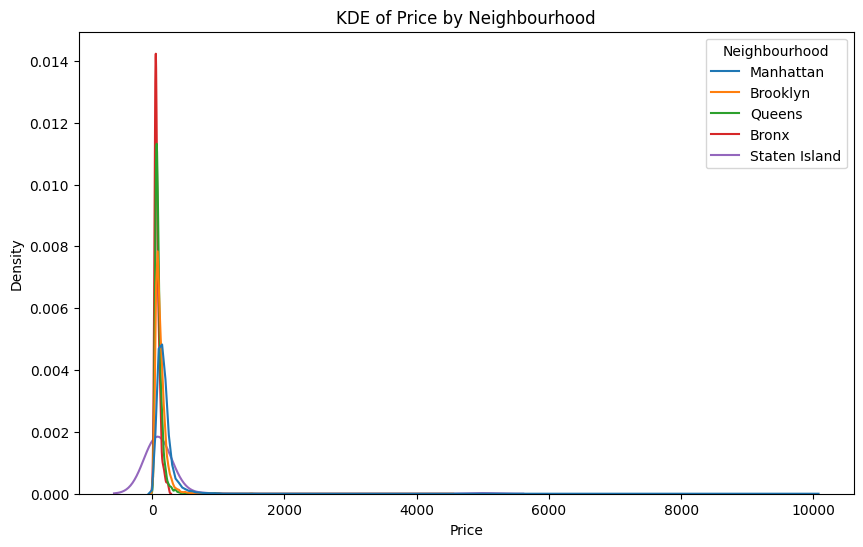

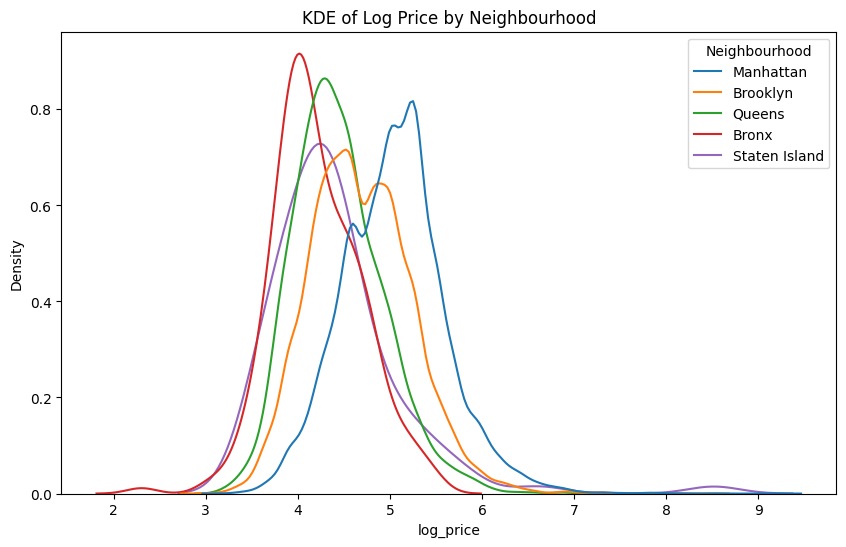

In [17]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x="Price", hue="Neighbourhood", common_norm=False)
plt.title("KDE of Price by Neighbourhood")
plt.show()

plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood", common_norm=False)
plt.title("KDE of Log Price by Neighbourhood")
plt.show()

2. 

In [31]:
D = pd.get_dummies(df["Neighbourhood"], drop_first=True).astype(int)
D.head()

,Brooklyn,Manhattan,Queens,Staten Island
0,0,1,0,0
1,1,0,0,0
2,0,1,0,0
3,1,0,0,0
4,0,1,0,0


In [33]:
from sklearn.linear_model import LinearRegression

In [37]:
X = D
y = df["Price"]
model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 75.27649769584667


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


In [38]:
avg_n

,Price,Review Scores Rating
Neighbourhood,,
Manhattan,183.664286,91.801496
Staten Island,146.166667,90.843750
Brooklyn,127.747378,92.363497
Queens,96.857233,91.549057
Bronx,75.276498,91.654378


Bronx is the omitted reference group, so the intercept is the average price in the Bronx, and each coefficient shows how much more expensive that neighbourhood is compared to the Bronx. If you add a neighbourhood’s coefficient to the intercept, you get that neighbourhood’s average price. 

To summarizes the interpretations:

Brooklyn is $52.47 more than Bronx on average

Manhattan is $108.39 more than Bronx on average

Queens is $21.58 more than Bronx on average

Staten Island is $70.89 more than Bronx on average

3.

In [41]:
X = df[["Review Scores Rating"]]
y = df["Price"]

reg = LinearRegression()
reg.fit(X, y)

print("Intercept:", reg.intercept_)
print("Slope:", reg.coef_[0])

Intercept: 60.878390657123816
Slope: 1.0208266022674735


On average, for each 1-point increase in Review Scores Rating, the predicted price changes by $1.02083 (slope) amount.

4.

In [52]:
X = pd.concat([df[["Review Scores Rating"]], D], axis=1)
y = df[["Price"]]

reg = LinearRegression()
reg.fit(X, y)

print("Intercept:", reg.intercept_)
print("Slope coefficient: ")

for var, coef in zip(X.columns, reg.coef_.ravel()):
    print(f"{var}: {coef}")

Intercept: [-23.81256101]
Slope coefficient: 
Review Scores Rating: 1.0811164834598528
Brooklyn: 51.70424015591067
Manhattan: 108.22873656676593
Queens: 21.694599576537126
Staten Island: 71.76655213403446


In [55]:
old_table = pd.DataFrame({
    "variable": model.feature_names_in_,
    "old_coef": model.coef_.ravel()
})

new_table = pd.DataFrame({
    "variable": X.columns,
    "new_coef": reg.coef_.ravel()
})

compare = pd.merge(old_table, new_table, on="variable", how="outer")
compare["change"] = compare["new_coef"] - compare["old_coef"]


compare = compare.drop(3)
compare

,variable,old_coef,new_coef,change
0,Brooklyn,52.470881,51.704240,-0.766640
1,Manhattan,108.387789,108.228737,-0.159052
2,Queens,21.580735,21.694600,0.113865
4,Staten Island,70.890169,71.766552,0.876383


Slope coefficient on Review Scores Rating increased by about 0.0603. After controlling for neighbourhood, a 1-point increase in review score is associated with about a $1.08 increase in predicted price on average. The neighbourhood coefficients change only a little after adding Review Scores Rating. Brooklyn falls from 52.47 to 51.70, Manhattan falls from 108.39 to 108.23, Queens rises from 21.58 to 21.69, and Staten Island rises from 70.89 to 71.77. So controlling for review score does not change the neighbourhood price differences very much.

5.

In [57]:
for col in D.columns:
    X[f"{col}_x_Review"] = D[col] * df["Review Scores Rating"]

y = df["Price"]

reg_int = LinearRegression()
reg_int.fit(X, y)

print("Intercept:", reg_int.intercept_)
for var, coef in zip(X.columns, reg_int.coef_):
    print(f"{var}: {coef}")

Intercept: 22.638384922064745
Review Scores Rating: 0.5743109493637346
Brooklyn: -16.392990175436147
Manhattan: 41.31542894848082
Queens: 28.259701286931204
Staten Island: 2963.071040120835
Brooklyn_x_Review: 0.7411652657450071
Manhattan_x_Review: 0.7297034445635944
Queens_x_Review: -0.07229434536605243
Staten Island_x_Review: -31.831747574076502


In [58]:
coefs = pd.Series(reg_int.coef_, index=X.columns)

base_slope = coefs["Review Scores Rating"]

slope_table = pd.DataFrame({
    "Neighbourhood": ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"],
    "Slope on Review Scores Rating": [
        base_slope,
        base_slope + coefs["Brooklyn_x_Review"],
        base_slope + coefs["Manhattan_x_Review"],
        base_slope + coefs["Queens_x_Review"],
        base_slope + coefs["Staten Island_x_Review"]
    ]
})

slope_table

,Neighbourhood,Slope on Review Scores Rating
0,Bronx,0.574311
1,Brooklyn,1.315476
2,Manhattan,1.304014
3,Queens,0.502017
4,Staten Island,-31.257437


The slopes are not very similar across neighbourhoods. Bronx and Queens have slopes around 0.5, Brooklyn and Manhattan have larger positive slopes around 1.3, and Staten Island has a very different negative slope of about -31.26. The relationship between review scores and price is not constant across neighbourhoods.

6.

In [59]:
from sklearn.model_selection import KFold, cross_val_score

In [64]:
D = pd.get_dummies(df["Neighbourhood"], drop_first=True).astype(int)
y = df["Price"]

X1 = df[["Review Scores Rating"]]

X2 = pd.concat([df[["Review Scores Rating"]], D], axis=1)

X3 = X2.copy()
for col in D.columns:
    X3[f"{col}_x_Review"] = D[col] * df["Review Scores Rating"]

kf = KFold(n_splits=5, shuffle=True, random_state=100)

cv1 = -cross_val_score(LinearRegression(), X1, y, cv=kf, scoring="neg_mean_squared_error")
cv2 = -cross_val_score(LinearRegression(), X2, y, cv=kf, scoring="neg_mean_squared_error")
cv3 = -cross_val_score(LinearRegression(), X3, y, cv=kf, scoring="neg_mean_squared_error")

results = pd.DataFrame({
    "model": ["Part 3", "Part 4", "Part 5"],
    "mean_cv_mse": [cv1.mean(), cv2.mean(), cv3.mean()],
    "std_cv_mse": [cv1.std(), cv2.std(), cv3.std()]
})

results

,model,mean_cv_mse,std_cv_mse
0,Part 3,22075.645732,8938.158311
1,Part 4,21067.497095,8982.542531
2,Part 5,21338.276988,8844.175782


The mean and standard deviation acorss the 3 models are very similar. Part 4 has the lowest average MSE so it may me a slightly more reliable model compared to the other ones.

**Question 3**

1.

In [65]:
df = pd.read_csv("cars_hw.csv")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [66]:
print(df["Price"].describe())

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


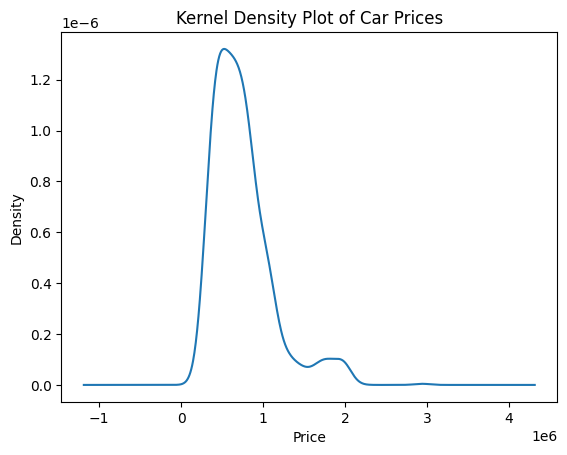

In [67]:
df["Price"].plot.kde()
plt.xlabel("Price")
plt.title("Kernel Density Plot of Car Prices")
plt.show()

In [68]:
price_by_body = df.groupby("Body_Type")["Price"].describe()
print(price_by_body)

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


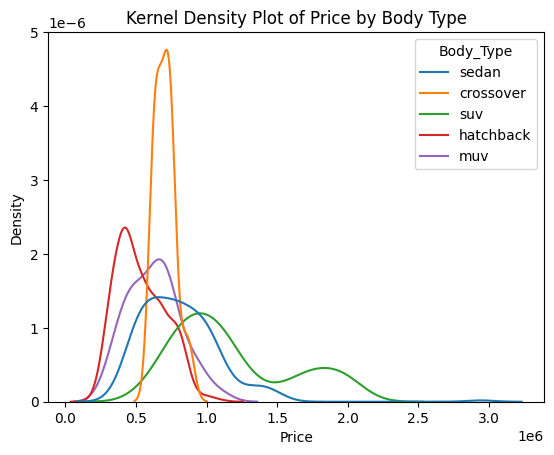

In [73]:
sns.kdeplot(data=df, x="Price", hue="Body_Type", common_norm=False)
plt.title("Kernel Density Plot of Price by Body Type")
plt.xlabel("Price")
plt.show()

SUVs have both the highest average price and the most variation in price among the body types.

2.

In [77]:
tdf = df.loc[:, ['Price', 'Seating_Capacity']].dropna()   
y = tdf['Price']                                          
X_num = tdf.loc[:, ['Seating_Capacity']] 

model_num = LinearRegression()
model_num = model_num.fit(X_num, y)

print(f"Model intercept: {model_num.intercept_}")
pd.DataFrame({'variable': model_num.feature_names_in_,
              'coefficient': model_num.coef_})

Model intercept: 439032.0141018268


,variable,coefficient
0,Seating_Capacity,59267.998037


Slope coefficient is 59267. Each additional seat is associated with about a $59268 increase in price on average.

In [79]:
X_seats = pd.get_dummies(tdf['Seating_Capacity'], dtype='int', drop_first=True)
model_cat = LinearRegression()
model_cat = model_cat.fit(X_seats, y)

print(f"Model intercept: {model_cat.intercept_}")
pd.DataFrame({
    'variable': X_seats.columns,
    'coefficient': model_cat.coef_
})

Model intercept: 188000.00000000163


,variable,coefficient
0,5,5.464839e+05
1,6,1.456000e+06
2,7,7.359487e+05
3,8,2.718000e+05


No, the differences in price are not roughly linear in the number of seats because the estimated prices do not increase steadily as seating capacity increases.

3.

In [80]:
df['Age'] = df['Make_Year'].max() - df['Make_Year']


tdf = df.loc[:, ['Price', 'Age']].dropna()
y = tdf['Price']


kf = KFold(n_splits=10, shuffle=True, random_state=3021)

cv_results = []
for p in range(1, 11):
    X = pd.DataFrame()
    
    for j in range(1, p + 1):
        X[f'Age^{j}'] = tdf['Age'] ** j
    
    model = LinearRegression()
    cv_mse = -cross_val_score(model,
                              X,
                              y,
                              cv=kf,
                              scoring='neg_mean_squared_error').mean()
    
    cv_results.append([p, cv_mse])

cv_results = pd.DataFrame(cv_results, columns=['num_powers', 'cv_mse'])
cv_results

,num_powers,cv_mse
0,1,9.760615e+10
1,2,9.786769e+10
2,3,9.728944e+10
3,4,9.686654e+10
4,5,9.605767e+10
5,6,9.614141e+10
6,7,9.541145e+10
7,8,9.450185e+10
8,9,9.419168e+10
9,10,9.432205e+10


Optimal power of age is 8.

4.

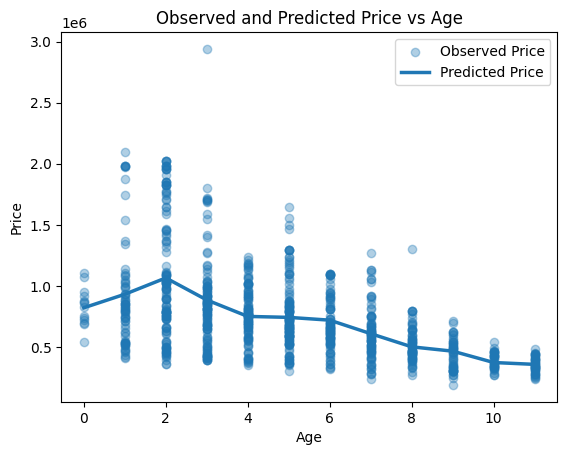

In [81]:
p = 8

X = pd.DataFrame()

for j in range(1, p + 1):
    X[f'Age^{j}'] = tdf['Age'] ** j

model = LinearRegression()
model.fit(X, y)

tdf['pred_price'] = model.predict(X)

tdf = tdf.sort_values('Age')

plt.scatter(tdf['Age'], tdf['Price'], alpha=0.35, label='Observed Price')

plt.plot(tdf['Age'], tdf['pred_price'], linewidth=2.5, label='Predicted Price')

plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Observed and Predicted Price vs Age')
plt.legend()
plt.show()

The model appears to fit the overall pattern in the data reasonably well because the predicted prices generally follow the downward trend as age increases, although there is still substantial scatter around the curve and some prices are not captured closely.

**Question 4**

In [82]:
df = pd.read_csv("heart_hw.csv")
df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


1.

In [86]:
survival_rates = df.groupby("transplant")["y"].mean()

ate = survival_rates["treatment"] - survival_rates["control"]

print(survival_rates)
print("ATE:", ate)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
ATE: 0.23017902813299232


2.

In [87]:
tdf = df.loc[:, ['y', 'transplant']].dropna()
y = tdf['y']

X = pd.get_dummies(tdf['transplant'], dtype='int', drop_first=True)

model = LinearRegression()
model.fit(X, y)

print(f"Model intercept: {model.intercept_}")

pd.DataFrame({
    'variable': X.columns,
    'coefficient': model.coef_
})

Model intercept: 0.11764705882352941


,variable,coefficient
0,treatment,0.230179


The intercept is 0.117647, which matches the survival proportion in the control group, and the transplant coefficient is 0.230179, which matches ATE from part 1.

3.

In [88]:
tdf = df.loc[:, ['y', 'transplant', 'age']].dropna()
y = tdf['y']

X = pd.get_dummies(tdf.loc[:, ['transplant', 'age']], dtype='int', drop_first=True)

model = LinearRegression()
model.fit(X, y)

print(f"Model intercept: {model.intercept_}")

pd.DataFrame({
    'variable': X.columns,
    'coefficient': model.coef_
})

Model intercept: 0.7019569721740946


,variable,coefficient
0,age,-0.013607
1,transplant_treatment,0.264702


When we control for age, the transplant coefficient increases from 0.230179 to 0.264702, so the estimated effect of a transplant becomes a little larger. The intercept, 0.701957, is the predicted survival probability for someone in the control group when age is 0, and the age coefficient, -0.013607, means the predicted probability of survival decreases by about 0.0136 for each additional year of age.

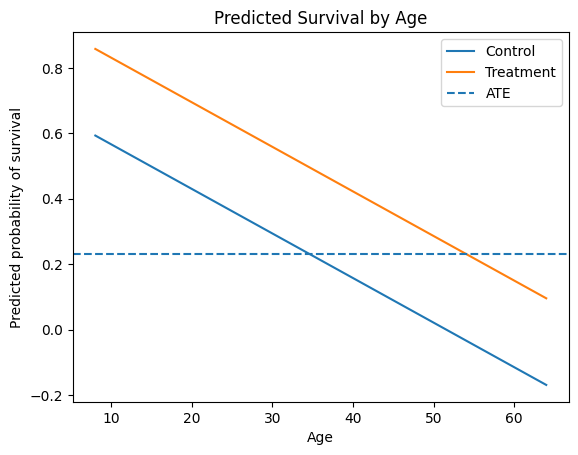

In [91]:
ages = np.arange(tdf['age'].min(), tdf['age'].max() + 1)

control_df = pd.DataFrame({
    'age': ages,
    'transplant_treatment': np.zeros(len(ages), dtype=int)
})

treat_df = pd.DataFrame({
    'age': ages,
    'transplant_treatment': np.ones(len(ages), dtype=int)
})

# Force the same column order as the training data
control_df = control_df[X.columns]
treat_df = treat_df[X.columns]

control_pred = model.predict(control_df)
treat_pred = model.predict(treat_df)

plt.plot(ages, control_pred, label='Control')
plt.plot(ages, treat_pred, label='Treatment')
plt.axhline(y=0.23017902813299232, linestyle='--', label='ATE')

plt.xlabel('Age')
plt.ylabel('Predicted probability of survival')
plt.title('Predicted Survival by Age')
plt.legend()
plt.show()

ATE underestimates the impact of a transplant for all ages because the fitted treatment and control lines are parallel and their vertical gap is larger than the dashed ATE line across the entire age range.

4.

In [95]:
tdf = df.loc[:, ['y', 'transplant', 'age']].dropna()
y = tdf['y']

X = pd.get_dummies(tdf['transplant'], dtype='int', drop_first=True)
X['age'] = tdf['age']
X['transplant_treatment * age'] = X['treatment'] * X['age']

model = LinearRegression()
model.fit(X, y)

print(f"Model intercept: {model.intercept_}")

pd.DataFrame({
    'variable': X.columns,
    'coefficient': model.coef_
})

Model intercept: 0.35486517529945866


,variable,coefficient
0,treatment,0.907751
1,age,-0.005524
2,transplant_treatment * age,-0.014591


When age and transplant interacts, it changes the predictions because the effect of a transplant is no longer constant across ages. The negative interaction coefficient (-0.014591) suggests that the benefit of a transplant gets smaller as age increases, so transplants appear more helpful for younger patients than for older patients.

5.

In [98]:
kf = KFold(n_splits = 10, shuffle = True, random_state = 3021)

#q2
tdf = df.loc[:, ['y', 'transplant']].dropna()
y = tdf['y']

X = pd.get_dummies(tdf['transplant'], dtype='int', drop_first=True)

model = LinearRegression()

cv_mse_2 = -cross_val_score(model,
                            X,
                            y,
                            cv = kf,
                            scoring = 'neg_mean_squared_error').mean()

cv_mse_2

#q3
tdf = df.loc[:, ['y', 'transplant', 'age']].dropna()
y = tdf['y']

X = pd.get_dummies(tdf.loc[:, ['transplant', 'age']], dtype='int', drop_first=True)

model = LinearRegression()

cv_mse_3 = -cross_val_score(model,
                            X,
                            y,
                            cv = kf,
                            scoring = 'neg_mean_squared_error').mean()

cv_mse_3

#q4
tdf = df.loc[:, ['y', 'transplant', 'age']].dropna()
y = tdf['y']

X = pd.get_dummies(tdf['transplant'], dtype='int', drop_first=True)
X['age'] = tdf['age']
X['transplant_treatment * age'] = X['treatment'] * X['age']

model = LinearRegression()

cv_mse_4 = -cross_val_score(model,
                            X,
                            y,
                            cv = kf,
                            scoring = 'neg_mean_squared_error').mean()
cv_mse_4



np.float64(0.1744301802007376)

In [97]:
pd.DataFrame({
    'model': ['transplant only', 'transplant + age', 'transplant + age + interaction'],
    'cv_mse': [cv_mse_2, cv_mse_3, cv_mse_4]
}).sort_values('cv_mse')

,model,cv_mse
2,transplant + age + interaction,0.174430
1,transplant + age,0.177389
0,transplant only,0.193236


Model from question 4 has the best predictive accuracy because it has the lowest MSE (0.174430), followed by the model from question 3 with an almost similar mse and finally the model from question one with only transplant performs worst. Therefore, adding age interactions with transplant may improve predictions slightly.

6.

One concern I have is that the model is built from past data, so it could learn patterns from an already unequal system and then use those patterns to justify who gets priority. For example, if some patients historically survived at higher rates not just because the transplant worked better for them, but because they had better hospitals, earlier referrals, after care... etc, the model might incorrectly treat those advantages as proof that they are better candidates for a transplant.